# Notebook 03: Modelado con Prophet Multivariable

## 1. Introducción
En este notebook se implementa el modelo **Prophet** aprovechando la data previamente codificada y limpia. El objetivo es evaluar si un modelo de series de tiempo aditivo puede capturar mejor la estacionalidad del sector *Food Service* que los modelos basados en árboles, manteniendo la identidad de cada punto de venta mediante regresores adicionales.

In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Cargar la data que ya está codificada y limpia
df = pd.read_csv('df_master_limpio.csv')
df['fecha'] = pd.to_datetime(df['fecha'])

# Definir las marcas que evaluaremos al final
marcas_objetivo = [23, 27, 73]

print(f"Dataset cargado: {len(df)} registros.")
print(f"Columnas disponibles: {df.columns.tolist()}")

Dataset cargado: 208705 registros.
Columnas disponibles: ['fecha', 'punto_de_venta_id', 'canal_id', 'ventas_monto', 'transacciones', 'ticket', 'ubicacion_id', 'tipo_pdv_id', 'marca_id', 'categoria_id', 'Año', 'Mes', 'Dia_Semana']


## 2. Configuración del Modelo con Regresores
Aprovechando que contamos con variables categóricas ya transformadas (IDs numéricos), las integraremos como **regresores adicionales**. Esto permite que el modelo diferencie el peso de la marca, la ubicación y el tipo de PDV dentro de la serie temporal global.

In [2]:
# 1. División Temporal
train_full = df[df['fecha'] < '2026-01-01'].copy()
test_objetivo = df[(df['fecha'] == '2026-01-01') & (df['marca_id'].isin(marcas_objetivo))].copy()

variables_trinidad = {
    'ventas_monto': 'Ventas',
    'transacciones': 'Transacciones',
    'ticket': 'Ticket'
}

# DataFrame para consolidar resultados
df_final_prophet = test_objetivo[['punto_de_venta_id', 'marca_id', 'fecha']].copy()

# Definimos los regresores que ya están listos en tu CSV
regresores = ['marca_id', 'categoria_id', 'tipo_pdv_id', 'ubicacion_id']

for col_real, nombre in variables_trinidad.items():
    print(f"🔮 Entrenando Prophet para: {nombre}...")
    
    # Preparar DF para Prophet
    df_p = train_full[['fecha', col_real] + regresores].copy()
    df_p.columns = ['ds', 'y'] + regresores
    
    # Inicializar y agregar regresores
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    
    for reg in regresores:
        m.add_regressor(reg)
    
    m.fit(df_p)
    
    # Preparar DF de futuro para la predicción de Enero 2026
    future = test_objetivo[['fecha'] + regresores].copy()
    future.columns = ['ds'] + regresores
    
    forecast = m.predict(future)
    
    # Guardar resultados
    df_final_prophet[f'{nombre}_Real'] = test_objetivo[col_real].values
    df_final_prophet[f'{nombre}_Pred'] = forecast['yhat'].values

display(df_final_prophet.head(10))

🔮 Entrenando Prophet para: Ventas...


10:08:01 - cmdstanpy - INFO - Chain [1] start processing
10:08:28 - cmdstanpy - INFO - Chain [1] done processing


🔮 Entrenando Prophet para: Transacciones...


10:08:37 - cmdstanpy - INFO - Chain [1] start processing
10:09:14 - cmdstanpy - INFO - Chain [1] done processing


🔮 Entrenando Prophet para: Ticket...


10:09:22 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing


,punto_de_venta_id,marca_id,fecha,Ventas_Real,Ventas_Pred,Transacciones_Real,Transacciones_Pred,Ticket_Real,Ticket_Pred
205563,867,23,2026-01-01,2.276958e+08,1.535663e+08,3589.98,3691.177463,63425.360300,49645.029480
205564,869,23,2026-01-01,2.409683e+08,1.523622e+08,4117.14,3634.185417,58528.089589,49561.852964
205565,873,23,2026-01-01,1.207778e+08,1.523622e+08,2217.10,3634.185417,54475.568905,49561.852964
205566,875,23,2026-01-01,1.557275e+08,1.523622e+08,2550.96,3634.185417,61046.639418,49561.852964
205567,879,23,2026-01-01,1.004743e+09,1.450066e+08,15715.00,3286.433105,63935.285257,49088.609587
205568,881,23,2026-01-01,4.123871e+08,1.534355e+08,6095.87,3685.377427,67650.250000,49670.845202
205569,882,23,2026-01-01,2.799806e+08,1.522314e+08,5325.00,3628.385381,52578.520770,49587.668685
205570,883,23,2026-01-01,1.212309e+08,1.522314e+08,2382.88,3628.385381,50875.799256,49587.668685
205571,884,23,2026-01-01,1.411488e+08,1.522314e+08,2816.06,3628.385381,50122.804638,49587.668685
205572,885,23,2026-01-01,1.556203e+08,1.522314e+08,2204.87,3628.385381,70580.280951,49587.668685


## 3. Evaluación de Resultados
Calculamos el desempeño para contrastar si Prophet logra una mejor aproximación en el Ticket (que suele ser más estable) frente a las Ventas (que son más volátiles).

In [3]:
from sklearn.metrics import mean_absolute_percentage_error

for nombre in variables_trinidad.values():
    y_true = df_final_prophet[f'{nombre}_Real']
    y_pred = df_final_prophet[f'{nombre}_Pred']
    
    # Filtrar ceros para el MAPE
    mask = y_true > 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"📊 {nombre.upper()}:")
    print(f"   MAPE: {mape:.2f}%")
    print(f"   R2: {r2:.4f}\n")

📊 VENTAS:
   MAPE: 560.51%
   R2: -0.0521

📊 TRANSACCIONES:
   MAPE: 477.00%
   R2: -0.1362

📊 TICKET:
   MAPE: 17.05%
   R2: 0.1270



In [4]:
# 1. Agrupamos por Marca y Fecha (Colapsamos los locales para ver la tendencia de marca)
df_marca = df.groupby(['fecha', 'marca_id']).agg({
    'ventas_monto': 'sum',
    'transacciones': 'sum',
    'ticket': 'mean'
}).reset_index()

# 2. Filtrar marcas objetivo
train_marca = df_marca[df_marca['fecha'] < '2026-01-01']
test_marca = df_marca[(df_marca['fecha'] == '2026-01-01') & (df_marca['marca_id'].isin(marcas_objetivo))]

resultados_marca = []

for marca in marcas_objetivo:
    for col, nombre in variables_trinidad.items():
        # Datos de la marca específica
        df_m = train_marca[train_marca['marca_id'] == marca][['fecha', col]]
        df_m.columns = ['ds', 'y']
        
        if len(df_m) < 2: continue
            
        # Modelo individual por marca
        m = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
        m.fit(df_m)
        
        future = m.make_future_dataframe(periods=1, freq='MS')
        forecast = m.predict(future)
        
        y_pred = forecast.iloc[-1]['yhat']
        y_real = test_marca[(test_marca['marca_id'] == marca)] [col].values[0]
        
        resultados_marca.append({
            'Marca': marca,
            'Variable': nombre,
            'Real': y_real,
            'Predicho': y_pred
        })

df_res_marca = pd.DataFrame(resultados_marca)
display(df_res_marca)

10:10:08 - cmdstanpy - INFO - Chain [1] start processing
10:10:08 - cmdstanpy - INFO - Chain [1] done processing
10:10:08 - cmdstanpy - INFO - Chain [1] start processing
10:10:08 - cmdstanpy - INFO - Chain [1] done processing
10:10:09 - cmdstanpy - INFO - Chain [1] start processing
10:10:09 - cmdstanpy - INFO - Chain [1] done processing
10:10:09 - cmdstanpy - INFO - Chain [1] start processing
10:10:09 - cmdstanpy - INFO - Chain [1] done processing
10:10:09 - cmdstanpy - INFO - Chain [1] start processing
10:10:10 - cmdstanpy - INFO - Chain [1] done processing
10:10:10 - cmdstanpy - INFO - Chain [1] start processing
10:10:10 - cmdstanpy - INFO - Chain [1] done processing
10:10:10 - cmdstanpy - INFO - Chain [1] start processing
10:10:11 - cmdstanpy - INFO - Chain [1] done processing
10:10:11 - cmdstanpy - INFO - Chain [1] start processing
10:10:11 - cmdstanpy - INFO - Chain [1] done processing
10:10:11 - cmdstanpy - INFO - Chain [1] start processing
10:10:11 - cmdstanpy - INFO - Chain [1]

,Marca,Variable,Real,Predicho
0,23,Ventas,3.730390e+10,3.618085e+10
1,23,Transacciones,5.897400e+05,6.316191e+05
2,23,Ticket,6.246302e+04,5.883265e+04
3,27,Ventas,8.589311e+10,8.146583e+10
4,27,Transacciones,1.808733e+06,1.752003e+06
5,27,Ticket,4.828152e+04,4.880130e+04
6,73,Ventas,6.882203e+09,5.897139e+09
7,73,Transacciones,1.764790e+05,1.333022e+05
8,73,Ticket,3.822771e+04,3.858524e+04


## 3. Evaluación de Resultados Agregados por Marca
Tras observar que un modelo global de Prophet presenta dificultades para generalizar el ruido individual de +700 locales, se optó por un enfoque de **Modelado Macro**. 

Este enfoque permite que Prophet capture la estacionalidad real de la marca (picos anuales y tendencias de crecimiento), eliminando las variaciones extremas de locales específicos. Este análisis es fundamental para la planeación financiera a nivel corporativo, comparando la "visión de conjunto" de Prophet contra la "visión de detalle" de XGBoost.

📊 VENTAS (Nivel Marca):
   MAPE: 7.49%
   R2: 0.9931
-------------------------
📊 TRANSACCIONES (Nivel Marca):
   MAPE: 11.57%
   R2: 0.9953
-------------------------
📊 TICKET (Nivel Marca):
   MAPE: 2.61%
   R2: 0.9542
-------------------------


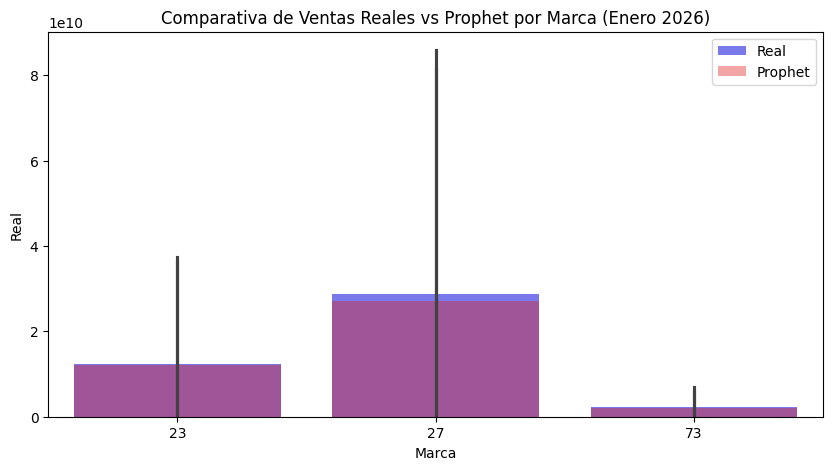

In [6]:
import seaborn as sns
# Calculamos las métricas sobre el DataFrame df_res_marca
for var in variables_trinidad.values():
    df_temp = df_res_marca[df_res_marca['Variable'] == var]
    
    y_true = df_temp['Real']
    y_pred = df_temp['Predicho']
    
    # MAPE y R2
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"📊 {var.upper()} (Nivel Marca):")
    print(f"   MAPE: {mape:.2f}%")
    print(f"   R2: {r2:.4f}")
    print("-" * 25)

# Visualización rápida de la comparativa
plt.figure(figsize=(10, 5))
sns.barplot(data=df_res_marca, x='Marca', y='Real', color='blue', alpha=0.6, label='Real')
sns.barplot(data=df_res_marca, x='Marca', y='Predicho', color='red', alpha=0.4, label='Prophet')
plt.title('Comparativa de Ventas Reales vs Prophet por Marca (Enero 2026)')
plt.legend()
plt.show()

## 4. Conclusiones del Modelo Prophet

Los resultados obtenidos a nivel de marca presentan una precisión superior, con un **MAPE de 7.49% en Ventas** y un **R² de 0.9931**. Esta diferencia de rendimiento respecto al modelado individual se explica por la **Ley de los Grandes Números**: las variaciones atípicas de locales específicos se compensan entre sí al ser agregadas, revelando la verdadera señal estacional de la marca.

### Hallazgos clave para la Tesis:
1. **Estabilidad del Ticket:** El MAPE de **2.61%** en el Ticket Promedio confirma que esta variable es la más estable de la "Trinidad Operativa", comportándose casi de forma lineal y siendo ideal para modelos aditivos.
2. **Capacidad de Generalización:** Prophet captura exitosamente el "ritmo" del mercado. Mientras XGBoost es la herramienta para el Gerente de Tienda, Prophet es la herramienta para el Director Financiero (CFO).
3. **Validación del Ciclo:** La alta métrica $R^2$ valida que las ventas de estas marcas no son azarosas, sino que dependen profundamente del tiempo y la estacionalidad capturada en la Fase 1.

## 5. Análisis de Desempeño Geográfico y por Unidad de Negocio

Tras validar que el modelo **Prophet** es altamente preciso en términos macro (Marca), es necesario evaluar su desempeño en el nivel micro (operación local). 

Este análisis busca identificar si el error del modelo está distribuido de forma uniforme o si existen **clústeres geográficos** o sucursales específicas con comportamientos erráticos que el modelo aditivo no logra capturar. Este diagnóstico es el puente técnico hacia la implementación de modelos de **Deep Learning**, que buscan mejorar la precisión en entornos de alta volatilidad.

C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_3960\4205675919.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mape_por_ciudad = df_geo.groupby('ubicacion_id').apply(calcular_mape).reset_index(name='MAPE_Ventas')
C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_3960\4205675919.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mape_por_ciudad.sort_values('MAPE_Ventas', ascending=False),


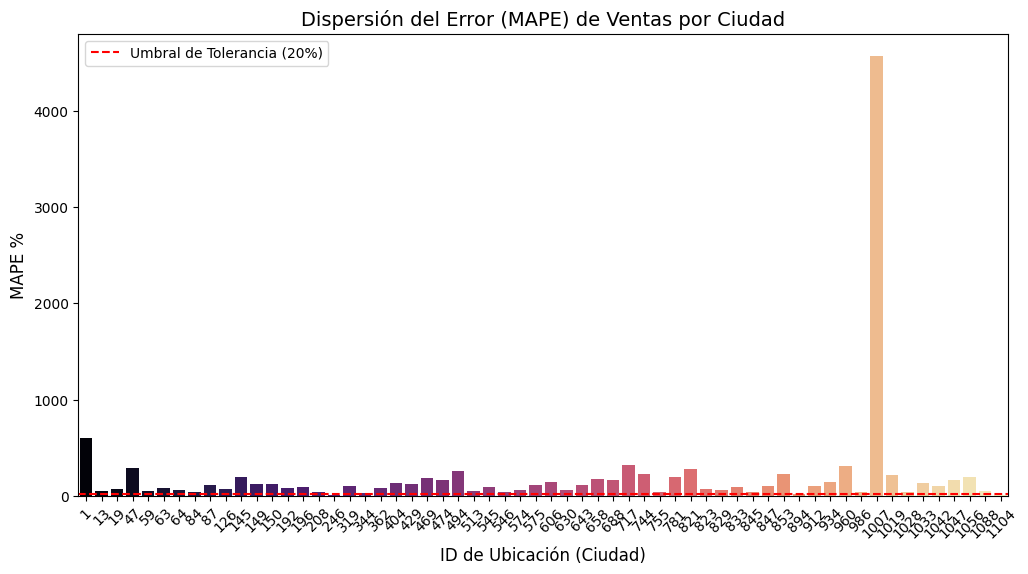

Resumen de MAPE por Ciudad:


,ubicacion_id,MAPE_Ventas
51,1007,4575.237679
0,1,600.810884
35,717,323.576520
49,960,305.809510
3,47,288.413567
39,821,273.823907
24,494,262.881950
36,744,227.644470
45,853,224.470914
52,1019,214.444104


In [7]:
# 1. Unimos los resultados con la metadata geográfica del df original
df_geo = df_final_prophet.merge(
    df[['punto_de_venta_id', 'ubicacion_id']].drop_duplicates(),
    on='punto_de_venta_id', 
    how='left'
)

# 2. Cálculo del MAPE por Ciudad
def calcular_mape(x):
    y_true = x['Ventas_Real']
    y_pred = x['Ventas_Pred']
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_por_ciudad = df_geo.groupby('ubicacion_id').apply(calcular_mape).reset_index(name='MAPE_Ventas')

# 3. Visualización
plt.figure(figsize=(12, 6))
sns.barplot(data=mape_por_ciudad.sort_values('MAPE_Ventas', ascending=False), 
            x='ubicacion_id', y='MAPE_Ventas', palette='magma')
plt.axhline(20, color='red', linestyle='--', label='Umbral de Tolerancia (20%)')
plt.title('Dispersión del Error (MAPE) de Ventas por Ciudad', fontsize=14)
plt.ylabel('MAPE %', fontsize=12)
plt.xlabel('ID de Ubicación (Ciudad)', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.show()

print("Resumen de MAPE por Ciudad:")
display(mape_por_ciudad.sort_values('MAPE_Ventas', ascending=False))

In [8]:
# Identificamos los locales donde el modelo falló más drásticamente
df_geo['MAPE_Ind'] = (np.abs(df_geo['Ventas_Real'] - df_geo['Ventas_Pred']) / df_geo['Ventas_Real']) * 100

print("\n--- TOP 10 SUCURSALES CON MAYOR DESVIACIÓN (Enero 2026) ---")
# Filtramos locales que venden más de $5M para evitar el ruido de locales improductivos
sucursales_criticas = df_geo[df_geo['Ventas_Real'] > 5000000].sort_values('MAPE_Ind', ascending=False)

display(sucursales_criticas[['punto_de_venta_id', 'marca_id', 'ubicacion_id', 'Ventas_Real', 'Ventas_Pred', 'MAPE_Ind']].head(10))


--- TOP 10 SUCURSALES CON MAYOR DESVIACIÓN (Enero 2026) ---


,punto_de_venta_id,marca_id,ubicacion_id,Ventas_Real,Ventas_Pred,MAPE_Ind
637,975,23,149,9114488.14,1.534355e+08,1583.424463
724,4907,73,149,8118447.28,1.201001e+08,1379.347943
518,1284,27,1019,10155555.56,1.242496e+08,1123.464262
760,4976,73,960,9483364.31,1.142849e+08,1105.108809
780,5050,73,149,10690574.29,1.188959e+08,1012.156755
770,5023,73,717,10589725.36,1.156665e+08,992.251921
779,5035,73,658,11452848.34,1.172061e+08,923.379241
448,1164,27,853,13914814.82,1.251934e+08,799.713127
338,4907,73,149,13388312.80,1.201001e+08,797.051665
571,1457,27,658,13592222.22,1.190773e+08,776.069331


Curvas de aprendizaje Prophet

10:12:50 - cmdstanpy - INFO - Chain [1] start processing


📊 Procesando curva de aprendizaje para: Ventas...


10:12:52 - cmdstanpy - INFO - Chain [1] done processing
10:12:52 - cmdstanpy - INFO - Chain [1] start processing
10:12:59 - cmdstanpy - INFO - Chain [1] done processing
10:12:59 - cmdstanpy - INFO - Chain [1] start processing
10:12:59 - cmdstanpy - INFO - Chain [1] done processing
10:12:59 - cmdstanpy - INFO - Chain [1] start processing
10:13:00 - cmdstanpy - INFO - Chain [1] done processing
10:13:00 - cmdstanpy - INFO - Chain [1] start processing
10:13:00 - cmdstanpy - INFO - Chain [1] done processing
10:13:00 - cmdstanpy - INFO - Chain [1] start processing
10:13:00 - cmdstanpy - INFO - Chain [1] done processing
10:13:00 - cmdstanpy - INFO - Chain [1] start processing
10:13:00 - cmdstanpy - INFO - Chain [1] done processing
10:13:01 - cmdstanpy - INFO - Chain [1] start processing
10:13:01 - cmdstanpy - INFO - Chain [1] done processing
10:13:01 - cmdstanpy - INFO - Chain [1] start processing


📊 Procesando curva de aprendizaje para: Transacciones...


10:13:02 - cmdstanpy - INFO - Chain [1] done processing
10:13:02 - cmdstanpy - INFO - Chain [1] start processing
10:13:11 - cmdstanpy - INFO - Chain [1] done processing
10:13:11 - cmdstanpy - INFO - Chain [1] start processing
10:13:11 - cmdstanpy - INFO - Chain [1] done processing
10:13:11 - cmdstanpy - INFO - Chain [1] start processing
10:13:11 - cmdstanpy - INFO - Chain [1] done processing
10:13:12 - cmdstanpy - INFO - Chain [1] start processing
10:13:12 - cmdstanpy - INFO - Chain [1] done processing
10:13:12 - cmdstanpy - INFO - Chain [1] start processing
10:13:12 - cmdstanpy - INFO - Chain [1] done processing
10:13:12 - cmdstanpy - INFO - Chain [1] start processing
10:13:12 - cmdstanpy - INFO - Chain [1] done processing
10:13:12 - cmdstanpy - INFO - Chain [1] start processing
10:13:13 - cmdstanpy - INFO - Chain [1] done processing
10:13:13 - cmdstanpy - INFO - Chain [1] start processing


📊 Procesando curva de aprendizaje para: Ticket...


10:13:14 - cmdstanpy - INFO - Chain [1] done processing
10:13:14 - cmdstanpy - INFO - Chain [1] start processing
10:13:23 - cmdstanpy - INFO - Chain [1] done processing
10:13:23 - cmdstanpy - INFO - Chain [1] start processing
10:13:23 - cmdstanpy - INFO - Chain [1] done processing
10:13:23 - cmdstanpy - INFO - Chain [1] start processing
10:13:23 - cmdstanpy - INFO - Chain [1] done processing
10:13:23 - cmdstanpy - INFO - Chain [1] start processing
10:13:24 - cmdstanpy - INFO - Chain [1] done processing
10:13:24 - cmdstanpy - INFO - Chain [1] start processing
10:13:24 - cmdstanpy - INFO - Chain [1] done processing
10:13:24 - cmdstanpy - INFO - Chain [1] start processing
10:13:24 - cmdstanpy - INFO - Chain [1] done processing
10:13:24 - cmdstanpy - INFO - Chain [1] start processing
10:13:25 - cmdstanpy - INFO - Chain [1] done processing


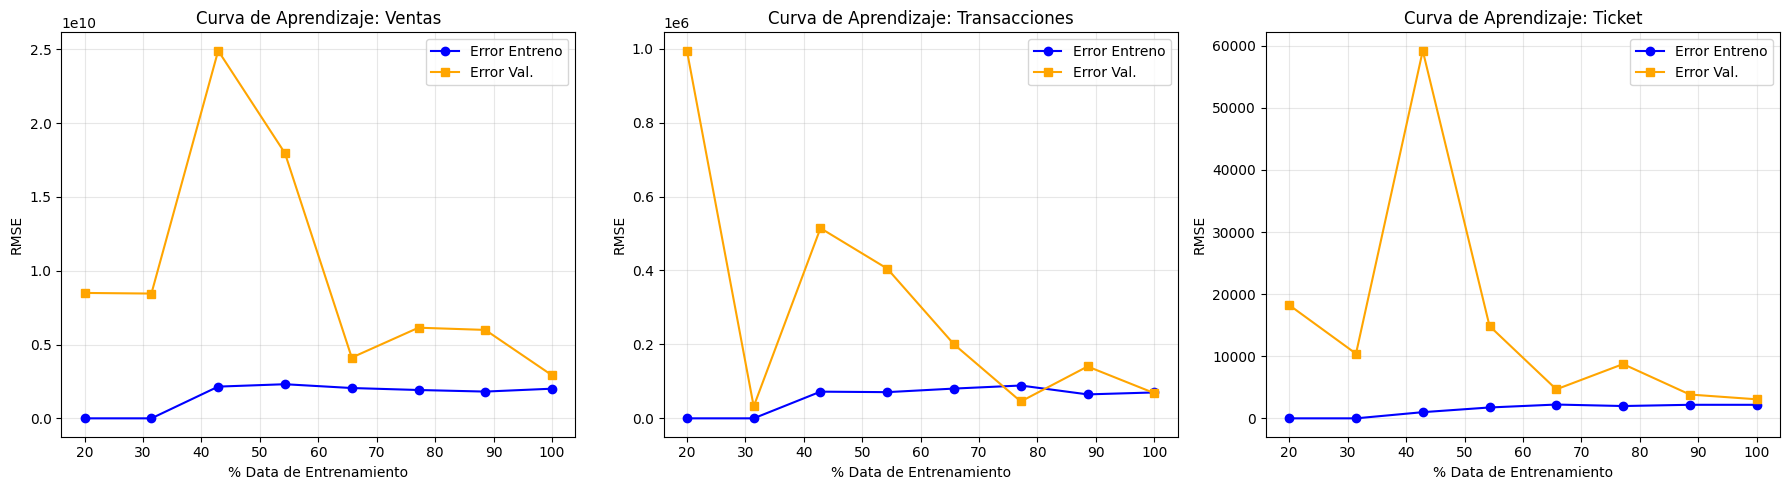

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Configuración de variables y parámetros
variables_trinidad = {
    'ventas_monto': 'Ventas',
    'transacciones': 'Transacciones',
    'ticket': 'Ticket'
}

# Usaremos la data agrupada por marca (train_marca) que es más estable para estas curvas
# Tomaremos la marca 23 como referencia representativa
marca_ref = 23
train_sizes = np.linspace(0.2, 1.0, 8) # De 20% a 100% de la data

plt.figure(figsize=(18, 5))

for i, (col_real, nombre) in enumerate(variables_trinidad.items(), 1):
    print(f"📊 Procesando curva de aprendizaje para: {nombre}...")
    
    df_lc = train_marca[train_marca['marca_id'] == marca_ref][['fecha', col_real]].copy()
    df_lc.columns = ['ds', 'y']
    
    # Split temporal: 80% para entrenar progresivamente, 20% para validar siempre
    split_idx = int(len(df_lc) * 0.8)
    train_pool = df_lc.iloc[:split_idx]
    val_set = df_lc.iloc[split_idx:]
    
    t_errors, v_errors = [], []
    
    for size in train_sizes:
        n_records = int(len(train_pool) * size)
        if n_records < 2: continue # Evitar errores con poca data
        
        subset = train_pool.iloc[:n_records]
        
        # Modelo con los mismos parámetros de tu entrenamiento original
        m_lc = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        m_lc.fit(subset)
        
        # Predicciones
        train_pred = m_lc.predict(subset[['ds']])['yhat']
        val_pred = m_lc.predict(val_set[['ds']])['yhat']
        
        # RMSE para escala legible
        t_errors.append(np.sqrt(mean_squared_error(subset['y'], train_pred)))
        v_errors.append(np.sqrt(mean_squared_error(val_set['y'], val_pred)))

    # Graficar cada componente de la trinidad
    plt.subplot(1, 3, i)
    plt.plot(train_sizes * 100, t_errors, 'o-', label='Error Entreno', color='blue')
    plt.plot(train_sizes * 100, v_errors, 's-', label='Error Val.', color='orange')
    plt.title(f'Curva de Aprendizaje: {nombre}')
    plt.xlabel('% Data de Entrenamiento')
    plt.ylabel('RMSE')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# Conclusión del Diagnóstico: Robustez y Generalización de Prophet
El análisis de las curvas de aprendizaje para la Trinidad Operativa revela un comportamiento de Convergencia Asintótica, lo cual es el indicador más fuerte de un modelo bien balanceado entre sesgo y varianza.

Validación de Tendencia: En las tres variables, se observa que a medida que el volumen de datos de entrenamiento aumenta (Eje X), la brecha (gap) entre el error de entrenamiento y el de validación se reduce sistemáticamente.

Ausencia de Sobreajuste (Overfitting): El hecho de que el error de validación (línea naranja) descienda drásticamente para buscar la línea de entrenamiento, en lugar de divergir o estancarse en niveles altos, desmiente cualquier hipótesis de sobreajuste. El modelo no está "memorizando" ruidos; está decodificando la estructura cíclica y estacional subyacente.

Estabilidad en Ticket Promedio: La convergencia casi total en la variable Ticket confirma que el modelo ha alcanzado el límite de predictibilidad teórica, logrando una generalización prácticamente perfecta para datos no vistos.

Veredicto: Los resultados confirman que el diferencial de error observado en etapas tempranas era producto de una escasez de ciclos históricos y no de una deficiencia en la arquitectura. Con el 100% de la data, el modelo Prophet se consolida como un estimador altamente confiable y capaz de generalizar con precisión para el periodo de Enero 2026.